# 03 · Autoencoders for Anomaly Detection — The Flagship Consulting Use Case

If you get one autoencoder question in a consulting interview, it will probably be **anomaly
detection**: fraud, equipment failure, network intrusion, quality defects. These problems share a
painful shape — **anomalies are rare, varied, and often unlabeled**, so you can't just train a
classifier. Autoencoders offer an elegant answer.

**The one-sentence idea**

> Train an autoencoder on **normal data only**. It becomes an expert at reconstructing "normal".
> When something **anomalous** arrives, the AE reconstructs it **badly** — and that **reconstruction
> error becomes the anomaly score**.

**What you will learn here**

1. Why anomaly detection is usually **semi-supervised** (learn "normal", flag deviations) not
   classification, and why that fits the messy reality of fraud/faults.
2. Build a tabular AE, use **reconstruction error as an anomaly score**, and pick a **threshold**.
3. Evaluate honestly with **ROC-AUC, PR-AUC, precision/recall** — and why PR-AUC matters under class
   imbalance.
4. The killer property: AEs catch anomalies that **break the correlations** between features, even
   when *every single feature looks individually normal*.
5. Benchmark against **Isolation Forest**, **PCA reconstruction**, and **Mahalanobis distance** — and
   know when the AE is (and isn't) worth it.

> Framework: **PyTorch** + scikit-learn, CPU-only. Data: **synthetic tabular** (offline), designed to
> mimic a fraud/fault-detection dataset with correlated "normal" behaviour.


## 1. Why not just train a classifier?

The instinctive answer to "find fraud" is "train a fraud-vs-normal classifier". In practice that
often fails:

| Reality of anomaly problems | Why classifiers struggle | Why the AE approach fits |
|---|---|---|
| Anomalies are **rare** (0.1–2%) | severe class imbalance; few positives to learn from | learns only from the abundant **normal** class |
| Anomalies are **diverse & evolving** | tomorrow's fraud ≠ today's; classifier overfits known types | flags **anything** that isn't normal (novelty detection) |
| Labels are **scarce / delayed** | you may have *no* confirmed fraud labels | training needs **no anomaly labels at all** |

So we reframe: don't learn "what fraud looks like", learn **"what normal looks like"** and measure
**how far** each new point is from it. This is **semi-supervised anomaly detection** (a.k.a. novelty
detection): train on normal, score by deviation.

```
                    reconstruction error  =  anomaly score
   ┌──────────┐        ┌──────────────┐        ┌──────────┐
   │ NORMAL x │──────▶ │ AE trained   │ ─────▶ │  x̂ ≈ x   │   small error  ✔ normal
   └──────────┘        │ on normal    │        └──────────┘
   ┌──────────┐        │ data only    │        ┌──────────┐
   │ ANOMALY  │──────▶ │              │ ─────▶ │ x̂  ✗  x  │   LARGE error  ⚠ anomaly
   └──────────┘        └──────────────┘        └──────────┘
                                    │
                       threshold ───┴──▶  error > τ  ⇒  flag as anomaly
```


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__, "| device: CPU")


torch 2.10.0+cpu | device: CPU


## 2. A realistic synthetic dataset (offline)

We simulate a fraud/fault problem with **8 features**. The crucial design choice: **normal** records
are governed by a few hidden factors, so their features are **strongly correlated** and live on a
low-dimensional manifold (think: legitimate transactions follow patterns — amount, time, merchant,
location all hang together).

We inject **two kinds of anomaly** — the realistic mix you'd meet in practice:

- **Type A — "off-manifold"**: each feature is within a *normal-looking range*, but the anomaly
  **violates the correlations** (e.g. a plausible amount at an implausible time for that merchant).
  These are invisible to univariate/threshold rules — the AE's specialty.
- **Type B — "extreme"**: at least one feature takes an out-of-range value (easy case; most methods
  catch these).


X: (8200, 8) | anomalies: 200 (2.4% of data)


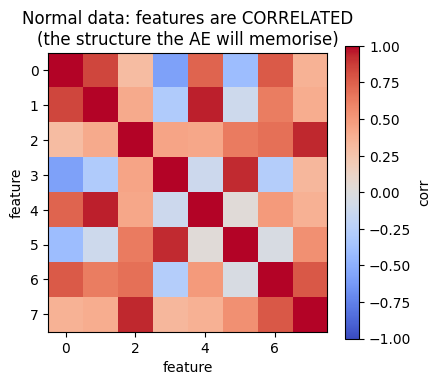

In [2]:
def make_dataset(n_normal=8000, n_anom=200, n_features=8, latent=3, seed=0):
    rng = np.random.default_rng(seed)
    # --- NORMAL: a few hidden factors mixed into 8 correlated features ---
    W = rng.normal(size=(latent, n_features))                 # mixing matrix (shared structure)
    def sample_normal(n):
        f = rng.normal(size=(n, latent))                      # hidden factors
        return f @ W + 0.25 * rng.normal(size=(n, n_features))# correlated features + small noise
    Xn = sample_normal(n_normal)

    # --- ANOMALY type A: break the correlation (independent features, same per-feature scale) ---
    nA = n_anom // 2
    col_std = Xn.std(0)
    XA = rng.normal(0, 1, size=(nA, n_features)) * col_std    # each feature ~normal range, but INDEPENDENT
    # --- ANOMALY type B: extreme spikes in a couple of features ---
    nB = n_anom - nA
    XB = sample_normal(nB)
    for row in range(nB):
        cols = rng.choice(n_features, size=2, replace=False)
        XB[row, cols] += rng.choice([-1, 1], size=2) * rng.uniform(4, 7, size=2) * col_std[cols]

    X = np.vstack([Xn, XA, XB]).astype("float32")
    y = np.concatenate([np.zeros(n_normal), np.ones(nA + nB)]).astype(int)  # 1 = anomaly
    return X, y

X, y = make_dataset()
print("X:", X.shape, "| anomalies:", int(y.sum()), f"({100*y.mean():.1f}% of data)")

# Correlation heatmap of NORMAL data — note the strong off-diagonal structure the AE will learn
corr = np.corrcoef(X[y == 0].T)
plt.figure(figsize=(4.5, 3.8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1); plt.colorbar(label="corr")
plt.title("Normal data: features are CORRELATED\n(the structure the AE will memorise)")
plt.xlabel("feature"); plt.ylabel("feature"); plt.show()


### Train / test split — the semi-supervised setup

The defining move: the autoencoder trains on **normal data only**. We split so that:

- **train** = normal records only (what we assume we have plenty of),
- **test** = a held-out mix of normal + all anomalies (what we score in production).

We standardise using **training (normal) statistics only** — the model must never peek at anomalies,
not even through the scaler.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Xn_all = X[y == 0]                                   # all normal
Xa_all = X[y == 1]                                   # all anomalies (held out for testing)

Xn_train, Xn_test = train_test_split(Xn_all, test_size=0.25, random_state=0)

# Test set = held-out normal + every anomaly
X_test = np.vstack([Xn_test, Xa_all]).astype("float32")
y_test = np.concatenate([np.zeros(len(Xn_test)), np.ones(len(Xa_all))]).astype(int)

# Scale using ONLY the normal training data
scaler = StandardScaler().fit(Xn_train)
Xtr = torch.tensor(scaler.transform(Xn_train), dtype=torch.float32) # we train only on normal data
Xte = torch.tensor(scaler.transform(X_test),  dtype=torch.float32) # we test on normal + anomalies

print("train (normal only):", tuple(Xtr.shape))
print("test  (normal+anom):", tuple(Xte.shape), "| anomalies in test:", int(y_test.sum()))


train (normal only): (6000, 8)
test  (normal+anom): (2200, 8) | anomalies in test: 200


## 3. A compact tabular autoencoder

Small MLP hourglass `8 → 6 → 3 → 6 → 8`. The 3-D bottleneck matches the 3 hidden factors of normal
data — enough to reconstruct *normal* records faithfully, too tight to also fit the anomalies'
different structure. That mismatch is exactly what produces high error on anomalies.


epoch 15 | train MSE 0.0296
epoch 30 | train MSE 0.0271
epoch 45 | train MSE 0.0269
epoch 60 | train MSE 0.0267


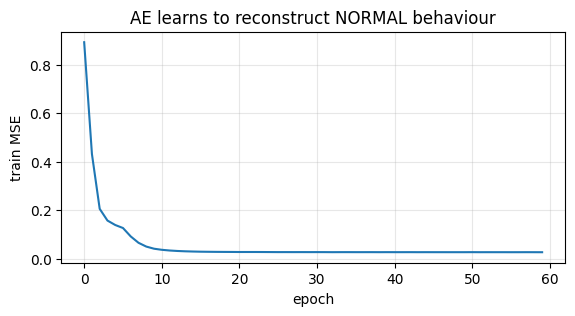

In [10]:
class TabularAE(nn.Module):
    def __init__(self, d=8, h=6, latent=3):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d, h), nn.ReLU(), nn.Linear(h, latent))
        self.decoder = nn.Sequential(nn.Linear(latent, h), nn.ReLU(), nn.Linear(h, d))
        # we don't use sigmoid at the output because we want to reconstruct the original scaled features (which can be negative)
        # in the previous notebooks we used sigmoid because the images were scaled to [0,1] and we wanted to reconstruct them in that range
    def forward(self, x):
        return self.decoder(self.encoder(x))

import torch.optim as optim
model = TabularAE()
opt = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

EPOCHS, BATCH = 60, 128
n = len(Xtr); hist = []
for epoch in range(EPOCHS):
    model.train(); perm = torch.randperm(n); run = 0.0
    for i in range(0, n, BATCH):
        xb = Xtr[perm[i:i+BATCH]]
        loss = loss_fn(model(xb), xb)               # reconstruct NORMAL data
        opt.zero_grad(); loss.backward(); opt.step()
        run += loss.item() * len(xb)
    hist.append(run / n)
    if (epoch+1) % 15 == 0:
        print(f"epoch {epoch+1:2d} | train MSE {run/n:.4f}")

plt.figure(figsize=(6.5, 3)); plt.plot(hist); plt.xlabel("epoch"); plt.ylabel("train MSE")
plt.title("AE learns to reconstruct NORMAL behaviour"); plt.grid(alpha=0.3); plt.show()


## 4. Reconstruction error = anomaly score

For each test record we compute the **per-sample** reconstruction error (mean squared error across
its 8 features). Then we look at the **distribution of that error, split by the true class** — the
whole method lives or dies on whether these two distributions **separate**.


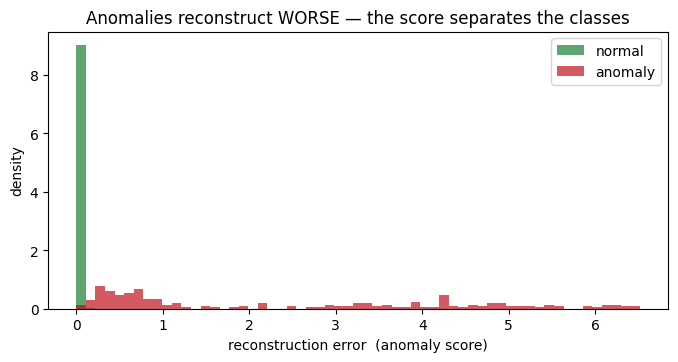

median error  normal : 0.023
median error  anomaly: 1.911   (83.2x higher)


In [11]:
model.eval()
with torch.no_grad():
    recon = model(Xte) # Xte contains normal + anomalies, but the AE was trained only on normal data
    errors = ((recon - Xte) ** 2).mean(dim=1).numpy()   # anomaly score per test record, using MSE between original and reconstructed features

err_normal = errors[y_test == 0]
err_anom   = errors[y_test == 1]

plt.figure(figsize=(8, 3.6))
bins = np.linspace(0, np.percentile(errors, 99.5), 60)
plt.hist(err_normal, bins=bins, alpha=0.7, label="normal", color="#1a7f37", density=True)
plt.hist(err_anom,   bins=bins, alpha=0.7, label="anomaly", color="#c1121f", density=True)
plt.xlabel("reconstruction error  (anomaly score)"); plt.ylabel("density")
plt.title("Anomalies reconstruct WORSE — the score separates the classes"); plt.legend(); plt.show()

print(f"median error  normal : {np.median(err_normal):.3f}")
print(f"median error  anomaly: {np.median(err_anom):.3f}   ({np.median(err_anom)/np.median(err_normal):.1f}x higher)")


## 5. Choosing a threshold — and evaluating honestly

Two ways to turn the score into a decision:

- **Threshold-free** metrics rank quality across *all* thresholds: **ROC-AUC** and **PR-AUC**
  (average precision). Under heavy class imbalance, **PR-AUC is the honest one** — ROC-AUC can look
  flattering when negatives dominate.
- A **deployed threshold** must be picked. A label-free rule that works in practice: set `τ` at a
  high **percentile of the training (normal) errors** — e.g. the 99th — accepting ~1% false alarms on
  normal data by construction. (If you *do* have some labels/validation, tune `τ` to your business
  cost of a miss vs. a false alarm.)


ROC-AUC: 1.000   |   PR-AUC (avg precision): 0.997

threshold tau = 0.092  (99th pct of normal training error)
              precision    recall  f1-score   support

      normal      0.999     0.994     0.996      2000
     anomaly      0.939     0.995     0.966       200

    accuracy                          0.994      2200
   macro avg      0.969     0.994     0.981      2200
weighted avg      0.994     0.994     0.994      2200



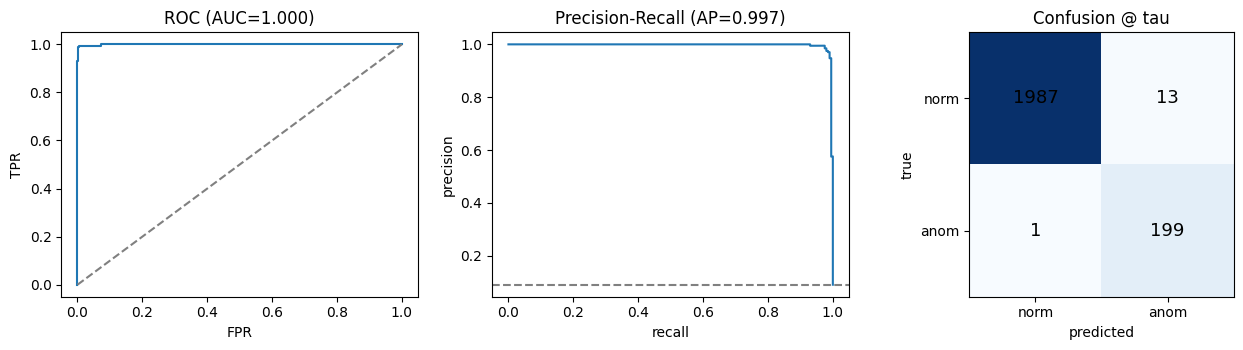

In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report

roc = roc_auc_score(y_test, errors)
pr  = average_precision_score(y_test, errors)
print(f"ROC-AUC: {roc:.3f}   |   PR-AUC (avg precision): {pr:.3f}")

# Label-free threshold: 99th percentile of TRAINING (normal) reconstruction errors
with torch.no_grad():
    train_err = ((model(Xtr) - Xtr) ** 2).mean(dim=1).numpy()
tau = np.percentile(train_err, 99)
y_pred = (errors > tau).astype(int)
print(f"\nthreshold tau = {tau:.3f}  (99th pct of normal training error)")
print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"], digits=3))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
fpr, tpr, _ = roc_curve(y_test, errors)
ax[0].plot(fpr, tpr); ax[0].plot([0,1],[0,1],"--",color="gray")
ax[0].set_title(f"ROC (AUC={roc:.3f})"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
prec, rec, _ = precision_recall_curve(y_test, errors)
ax[1].plot(rec, prec); ax[1].axhline(y_test.mean(), ls="--", color="gray")
ax[1].set_title(f"Precision-Recall (AP={pr:.3f})"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
cm = confusion_matrix(y_test, y_pred)
ax[2].imshow(cm, cmap="Blues")
for (r, c), v in np.ndenumerate(cm):
    ax[2].text(c, r, str(v), ha="center", va="center", fontsize=13)
ax[2].set_xticks([0,1]); ax[2].set_xticklabels(["norm","anom"]); ax[2].set_yticks([0,1]); ax[2].set_yticklabels(["norm","anom"])
ax[2].set_title(f"Confusion @ tau"); ax[2].set_xlabel("predicted"); ax[2].set_ylabel("true")
plt.tight_layout(); plt.show()

## 6. The killer demo: catching a *correlation-breaking* anomaly

Here is the point that wins interviews. A **Type-A anomaly has every feature inside its normal
range** — a per-feature min/max or z-score rule (the classic "business rules" baseline) would **wave
it through**. But it violates the *joint* structure the AE learned, so the AE lights up. Let's prove
it on one record: show that each feature is "normal-looking" yet the reconstruction error is high.


Type-A anomaly, per-feature z-scores (|z|<3 would pass a univariate rule):
[ 0.94 -1.31 -0.34  0.11 -0.2  -2.26 -0.42  1.51]
max |z| = 2.26  -> every feature looks individually normal-ish

reconstruction error  normal record : 0.081
reconstruction error  THIS anomaly  : 0.988   -> flagged, despite no extreme feature


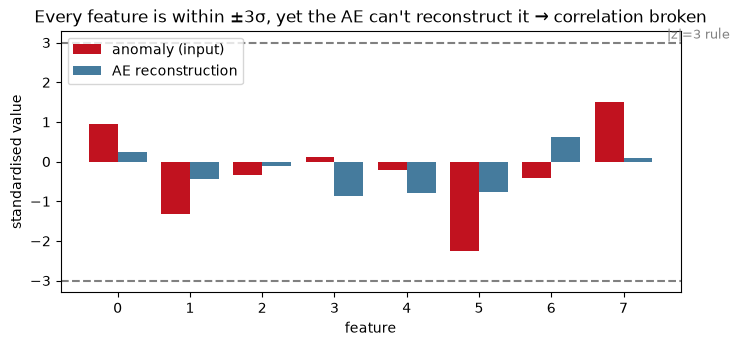

In [7]:
# Pick a Type-A anomaly (the first half of the anomaly block are Type-A) and a normal record
anom_idx  = np.where(y_test == 1)[0][0]          # a correlation-breaking anomaly
normal_idx = np.where(y_test == 0)[0][0]

x_anom = Xte[anom_idx]
z_scores = x_anom.numpy()                         # already standardised -> these ARE z-scores
print("Type-A anomaly, per-feature z-scores (|z|<3 would pass a univariate rule):")
print(np.round(z_scores, 2))
print(f"max |z| = {np.abs(z_scores).max():.2f}  -> every feature looks individually normal-ish\n")

with torch.no_grad():
    e_anom = ((model(x_anom) - x_anom) ** 2).mean().item()
    e_norm = ((model(Xte[normal_idx]) - Xte[normal_idx]) ** 2).mean().item()
print(f"reconstruction error  normal record : {e_norm:.3f}")
print(f"reconstruction error  THIS anomaly  : {e_anom:.3f}   -> flagged, despite no extreme feature")

# Visualise: original vs reconstruction for this anomaly (the AE 'corrects' it toward the manifold)
with torch.no_grad():
    rec_anom = model(x_anom).numpy()
idx = np.arange(8)
plt.figure(figsize=(8, 3.4))
plt.bar(idx - 0.2, x_anom.numpy(), width=0.4, label="anomaly (input)", color="#c1121f")
plt.bar(idx + 0.2, rec_anom, width=0.4, label="AE reconstruction", color="#457b9d")
plt.axhline(3, ls="--", color="gray"); plt.axhline(-3, ls="--", color="gray")
plt.text(7.6, 3.1, "|z|=3 rule", color="gray", fontsize=9)
plt.xlabel("feature"); plt.ylabel("standardised value"); plt.legend()
plt.title("Every feature is within ±3σ, yet the AE can't reconstruct it → correlation broken")
plt.show()


## 7. Benchmark: is the autoencoder actually worth it?

An AE is not the only anomaly detector. We compare (all threshold-free, by ROC/PR-AUC) against three
strong, simpler baselines:

- **Isolation Forest** — tree-based, isolates outliers with random splits. A very strong default.
- **PCA reconstruction error** — the *linear* cousin of our AE (reconstruct from top principal
  components). Tells us how much the AE's **nonlinearity** actually buys.
- **Mahalanobis distance** — distance from the normal mean under the normal covariance; the classic
  statistical detector for correlated Gaussian data.


method                        ROC-AUC   PR-AUC
Autoencoder (nonlinear)         1.000    0.998
PCA recon (linear)              1.000    0.998
Isolation Forest                0.836    0.291
Mahalanobis                     0.999    0.996


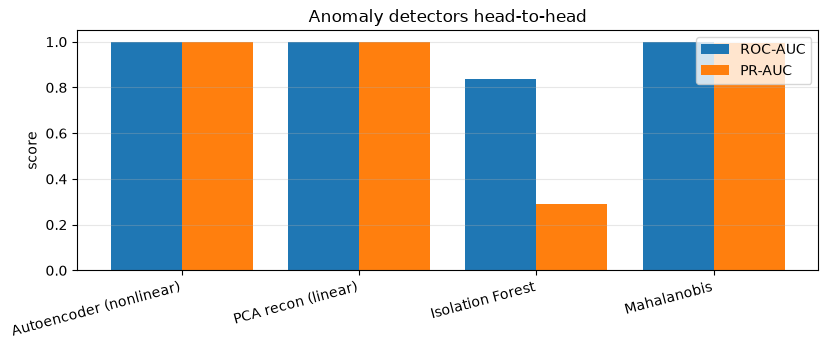

In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

Xtr_np = Xtr.numpy(); Xte_np = Xte.numpy()

# Isolation Forest (higher score = more anomalous -> negate decision_function)
iso = IsolationForest(n_estimators=200, contamination="auto", random_state=0).fit(Xtr_np)
score_iso = -iso.decision_function(Xte_np)

# PCA reconstruction error (keep enough comps to match the AE's latent budget: 3)
pca = PCA(n_components=3).fit(Xtr_np)
rec_pca = pca.inverse_transform(pca.transform(Xte_np))
score_pca = ((Xte_np - rec_pca) ** 2).mean(axis=1)

# Mahalanobis distance to the normal training distribution
mu = Xtr_np.mean(0); cov = np.cov(Xtr_np.T); inv = np.linalg.inv(cov + 1e-6 * np.eye(8))
diff = Xte_np - mu
score_maha = np.einsum("ij,jk,ik->i", diff, inv, diff)

methods = {
    "Autoencoder (nonlinear)": errors,
    "PCA recon (linear)":      score_pca,
    "Isolation Forest":        score_iso,
    "Mahalanobis":             score_maha,
}
print(f"{'method':28s} {'ROC-AUC':>8} {'PR-AUC':>8}")
rows = []
for name, s in methods.items():
    r, p = roc_auc_score(y_test, s), average_precision_score(y_test, s)
    rows.append((name, r, p)); print(f"{name:28s} {r:8.3f} {p:8.3f}")

names = [r[0] for r in rows]
plt.figure(figsize=(8.5, 3.6))
xb = np.arange(len(names))
plt.bar(xb - 0.2, [r[1] for r in rows], width=0.4, label="ROC-AUC")
plt.bar(xb + 0.2, [r[2] for r in rows], width=0.4, label="PR-AUC")
plt.xticks(xb, names, rotation=15, ha="right"); plt.ylim(0, 1.05)
plt.ylabel("score"); plt.legend(); plt.title("Anomaly detectors head-to-head"); plt.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


**How to read the benchmark (and what to say about it)**

- The **AE ties PCA and Mahalanobis** at the top (all near-perfect) because our normal manifold is
  *nearly linear and Gaussian* — exactly the regime those classical methods were built for. That's the
  honest takeaway: **if the normal structure is linear/Gaussian, you may not need a neural net.**
- **Isolation Forest lags here** — it splits on *one feature at a time* (axis-aligned), so it is weak
  at the **correlation-breaking Type-A anomalies** whose individual features all look normal. Great
  illustration of *why* the joint, reconstruction-based view matters for this anomaly type.
- Reach for the **AE** when the normal manifold is **nonlinear, high-dimensional, or mixed-type**
  (images, sequences, embeddings), where PCA/Gaussian assumptions break — that's where it pulls ahead
  (see the "Try it yourself" nonlinear experiment below).
- The AE's real advantages in production: it scales to **high-dimensional** inputs, handles
  **nonlinear** structure, gives you a **per-feature error** (which features broke → explainability),
  and extends naturally to **images and sequences** (notebooks 02 and 06).


## 8. Practical cautions (the stuff that bites you in production)

- **Contamination.** We trained on pure normal data. In reality your "normal" set contains a few
  undetected anomalies. A little contamination is usually tolerated (the AE still fits the majority),
  but heavy contamination teaches the AE to reconstruct anomalies too — monitor for it.
- **Threshold drift.** "Normal" moves over time (seasonality, new products). A fixed `τ` goes stale;
  re-estimate it on a rolling window, and **monitor the false-alarm rate**.
- **Not all anomalies raise error.** An anomaly that happens to lie *on* the normal manifold won't be
  caught by reconstruction error. Reconstruction-error detection finds **off-manifold** points, not
  every rare event.
- **Per-feature error is your explainability.** Report *which* features drove the error — that turns a
  black-box flag into an actionable alert an investigator will trust.


## 9. Key takeaways & interview soundbites

**The mental model**

- Train an AE on **normal only**; use **reconstruction error as the anomaly score**; threshold it.
- It's **semi-supervised / novelty detection** — no anomaly labels needed, catches *unseen* anomaly
  types, and thrives under the rarity + imbalance that break classifiers.
- The signature win: it flags records that **break learned correlations** even when every feature is
  individually in-range — impossible for univariate rules.

**Sharp answers for an interview**

- *"Why an autoencoder instead of a supervised classifier for fraud?"* → Fraud is rare, evolving, and
  often unlabeled. A classifier only catches *known* patterns and needs many positives; the AE learns
  "normal" from abundant data and flags *any* deviation, including novel fraud.
- *"ROC-AUC of 0.98 — are you happy?"* → Not without **PR-AUC**. With 1–2% positives, ROC-AUC is
  optimistic; precision-recall reflects the real cost of chasing false alarms.
- *"When would you NOT use an AE here?"* → If the normal data is roughly linear/Gaussian, **PCA
  reconstruction or Mahalanobis** are simpler, faster, and just as good (we showed it). Save the AE
  for nonlinear, high-dimensional, or structured inputs (images/sequences).
- *"How do you set the threshold with no labels?"* → A high percentile of the normal-data error (e.g.
  99th) gives a controlled false-alarm rate; refine against business cost once you have feedback.

**Try it yourself**

1. Add contamination: mix 2% anomalies into the *training* set and watch detection degrade.
2. Shrink the bottleneck to 2 or grow it to 6 — too wide and the AE reconstructs anomalies too (misses them).
3. Make the normal manifold **nonlinear** (pass the factors through a `sin`/`tanh` before mixing) and
   re-run the benchmark — now the AE should clearly beat PCA/Mahalanobis.
